## Final test on holdout dataset

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

Load data

In [9]:

def load_NPI_measurements(filepath=r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\NPI250to421.csv"):

    features = [
        "npi",
        "pupil_size",
        "pupil_min",
        "ch",
        "const_velocity",
        "max_const_velocity",
        "latency",
        "dilat_velocity",
    ]

    # Only load needed columns
    cols = ["record_id", "redcap_repeat_instance"]

    for feat in features:
        cols.extend([
            f"{feat}_right",
            f"{feat}_left",
            f"{feat}_right_2",
            f"{feat}_left_2",
        ])

    df = pd.read_csv(filepath, usecols=lambda c: c in cols)

    # Baseline rows have NaN repeat_instance
    df["redcap_repeat_instance"] = (
        df["redcap_repeat_instance"]
        .fillna(0)
        .astype(int)
    )

    # Follow-up rows store values in *_2 columns
    followup_mask = df["redcap_repeat_instance"] > 0

    for feat in features:
        for side in ["right", "left"]:

            normal_col = f"{feat}_{side}"
            followup_col = f"{feat}_{side}_2"

            df.loc[followup_mask, normal_col] = (
                df.loc[followup_mask, followup_col]
            )

    # Remove *_2 columns
    df = df.drop(
        columns=[c for c in df.columns if c.endswith("_2")]
    )

    # Remove rows where NPI is missing
    df = df.dropna(
        subset=["npi_right", "npi_left"],
        how="all"
    )

    # Rename repeat instance
    df = df.rename(
        columns={"redcap_repeat_instance": "instance"}
    )

# Make seperate dataframes

    right_cols = ["record_id", "instance"] + [c for c in df.columns if c.endswith("_right")]
    df_right = df[right_cols].copy()
    df_right.columns = [c.replace("_right", "") for c in df_right.columns]


    left_cols = ["record_id", "instance"] + [c for c in df.columns if c.endswith("_left")]
    df_left = df[left_cols].copy()
    df_left.columns = [c.replace("_left", "") for c in df_left.columns]

    return (df_right.reset_index(drop=True), df_left.reset_index(drop=True))

df_right, df_left = load_NPI_measurements()


Load healthy to create z-scores and remove rows with important missing values

In [10]:
df_l = pd.read_csv(r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\Pupilometri\HC_left_NPi.csv")
df_r = pd.read_csv(r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\Pupilometri\HC_right_NPi.csv")

df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)

def z_score(x, mean, std):
    return (x - mean) / std


# Keep only record_id >= 253
df_right = df_right[df_right["record_id"] >= 253].copy()
df_left = df_left[df_left["record_id"] >= 253].copy()

# Drop rows with missing values in required variables
required_cols = [
    "npi",
    "pupil_size",
    "pupil_min",
    "ch"
]

df_right = df_right.dropna(subset=required_cols)
df_left = df_left.dropna(subset=required_cols)

df_right = df_right.reset_index(drop=True)
df_left = df_left.reset_index(drop=True)



# Right eye
df_right["z_pupil_size"] = z_score(df_right["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df_right["z_pupil_min"] = z_score(df_right["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df_right["z_ch"] = z_score(df_right["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df_right["z_const_velocity"] = z_score(df_right["const_velocity"], df_HC["const_velocity"].dropna().mean(), df_HC["const_velocity"].dropna().std())
df_right["z_max_const_velocity"] = z_score(df_right["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df_right["z_dilat_velocity"] = z_score(df_right["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df_right["z_latency"] = z_score(df_right["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())


# Left eye
df_left["z_pupil_size"] = z_score(df_left["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df_left["z_pupil_min"] = z_score(df_left["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df_left["z_ch"] = z_score(df_left["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df_left["z_const_velocity"] = z_score(df_left["const_velocity"], df_HC["const_velocity"].dropna().mean(), df_HC["const_velocity"].dropna().std())
df_left["z_max_const_velocity"] = z_score(df_left["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df_left["z_dilat_velocity"] = z_score(df_left["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df_left["z_latency"] = z_score(df_left["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())


df_left["eye"] = "left"
df_right["eye"] = "right"

df = pd.concat([df_left, df_right], ignore_index=True)

In [11]:
print("size",df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
print("min",df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
print("ch",df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())

size 4.85 1.0441166562394906
min 3.0976000000000004 0.7601357558666338
ch 36.16 6.038515833330882


In [12]:
df.iloc[np.where(abs((df["pupil_size"] - df["pupil_min"]) / df["pupil_size"] - df["ch"] / 100) > 0.01)]

,record_id,instance,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,dilat_velocity,z_pupil_size,z_pupil_min,z_ch,z_const_velocity,z_max_const_velocity,z_dilat_velocity,z_latency,eye


### Test


=== PERFORMANCE ===
RMSE: 0.0864
MAE:  0.0521
R2:   0.9783


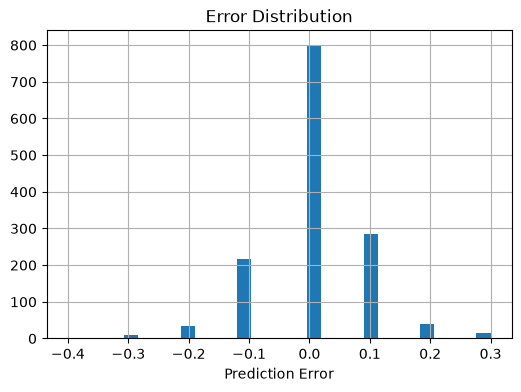

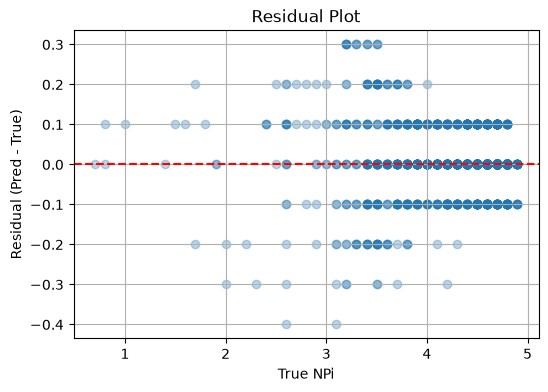

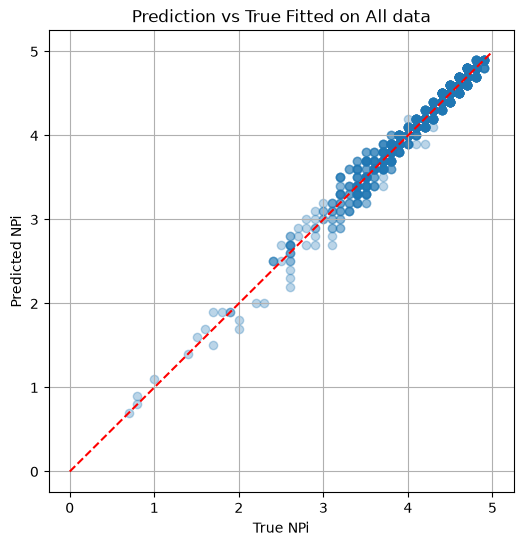

In [15]:
# Define x and y and what to group on
TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
    "z_ch"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values

# Define the models

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Pupil min model
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

#  pupil size model
def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
    return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b

def pysr_expr(x, a, b, c):
    return a * x**3 + np.sin(b * x**2) + c

#  CH model
def sigmoid_shifted(x, A, k, x0, b):
    return A * sigmoid(k * (x - x0)) + b



def pysr_min(x, a, b, c):
    return a * np.exp(-b * x) + c
    # return a + b / (c + d * np.exp(-x) + e / x)

def pysr_min(x, a, b, c):
    return (a + b * x) / (x + c)

def pysr_ch(x, a, b, c, d):
    return a * x + b * np.sin(c * x) + d

def pysr_size(x, a, b, c, d):
    return (a * x**3 + b*x + c) * np.sin(x + d)





# Parameters for each feature (From NPI_CV_minmaxch.ipynb (recontruction))
found_parameters = pd.read_csv("stored_values.csv", index_col=0)
params_size = found_parameters.loc["size"].values
params_min = found_parameters.loc["min"].values
params_ch = found_parameters.loc["ch"].values
intercept = found_parameters.loc["intercept"].values[0]
a = found_parameters.loc["a"].values[0]
b = found_parameters.loc["b"].values[0]

params_size = params_size[~np.isnan(params_size)]
params_min = params_min[~np.isnan(params_min)]
params_ch = params_ch[~np.isnan(params_ch)]
intercept = intercept[~np.isnan(intercept)]
a = a[~np.isnan(a)]
b = b[~np.isnan(b)]

def inverse_logit_transform(z, y_min=0.0, y_max=5.0):
    """
    Inverse logit-transform back to original scale.
    """
    y_scaled = 1 / (1 + np.exp(-z))
    return y_min + (y_max - y_min) * y_scaled

# Prediction model
def predict_z_full(X):
    return (
        intercept
        + pysr_size(X.iloc[:,0].values, *params_size)
        + exp_decay(X.iloc[:,1].values, *params_min)
        + pysr_ch(X.iloc[:,2].values, *params_ch)
    )

z_pred = predict_z_full(X)
z_final = a * z_pred + b

y_pred = np.round(sigmoid(z_final) * 5,1)
rmse = np.sqrt(mean_squared_error(y_raw, y_pred))
mae  = mean_absolute_error(y_raw, y_pred)
r2   = r2_score(y_raw, y_pred)

print("\n=== PERFORMANCE ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

residuals = y_pred-y_raw
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_raw, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("True NPi")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.grid()
plt.show()


plt.figure(figsize=(6,6))
plt.scatter(y_raw, y_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True Fitted on All data")
plt.grid()
plt.show()

In [36]:
ch_grid = np.linspace(df["z_ch"].min(), df["z_ch"].max(), 100)
size_grid = np.linspace(df["z_pupil_size"].min(), df["z_pupil_size"].max(), 100)
min_grid = np.linspace(df["z_pupil_min"].min(), df["z_pupil_min"].max(), 100)
X_grid = np.array(np.meshgrid(min_grid, ch_grid, size_grid)).T.reshape(-1, 3)

def predict_z_grid(X_grid):
    return (
        intercept
        + pysr_size(X_grid[:,0], *params_size)
        + exp_decay(X_grid[:,1], *params_min)
        + pysr_ch(X_grid[:,2], *params_ch)
    )

z_grid = predict_z_grid(X_grid)
z_grid_final = a * z_grid + b
z_final = np.asarray(a * z + b, dtype=float)
y_grid_pred = np.round(sigmoid(z_grid_final) * 5,1)

KeyboardInterrupt: 

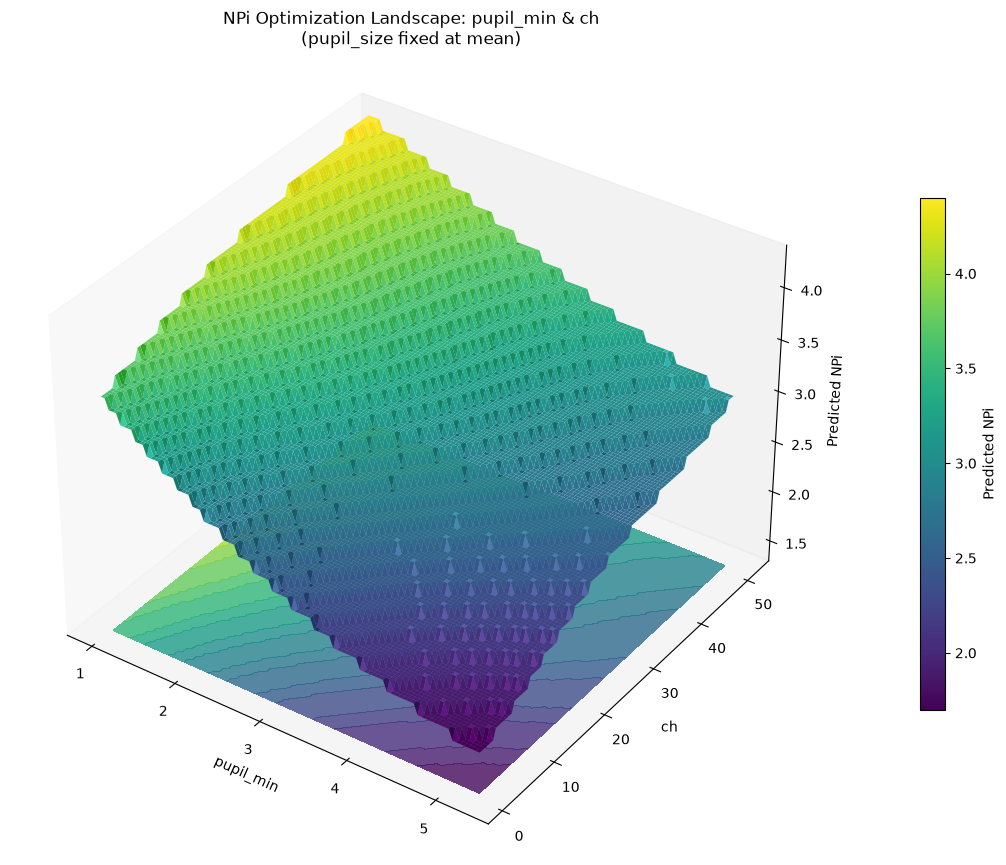

In [46]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.colors import LightSource

# Use a finer grid for a smoother landscape (n=100 grids you already built work well here)
Xz, Yz = np.meshgrid(min_grid, ch_grid, indexing="xy")
Z = predict_npi(Xz, Yz, 0.0)

Xv, Yv = np.meshgrid(min_grid_viz, ch_grid_viz, indexing="xy")

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

# --- Shaded relief surface (gives it that "terrain" depth) ---
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z, cmap=cm.viridis, vert_exag=0.3, blend_mode="soft")

surf = ax.plot_surface(
    Xv, Yv, Z,
    facecolors=rgb,
    rstride=1, cstride=1,
    linewidth=0, antialiased=True, shade=False
)

# --- Contour map projected onto the floor, like a topo map ---
zfloor = Z.min() - 0.15 * (Z.max() - Z.min())
ax.contourf(Xv, Yv, Z, zdir="z", offset=zfloor, cmap="viridis", levels=20, alpha=0.8)
ax.contour(Xv, Yv, Z, zdir="z", offset=zfloor, colors="k", linewidths=0.3, levels=20, alpha=0.4)

ax.set_zlim(zfloor, Z.max())

# --- Colorbar (using a ScalarMappable since facecolors bypasses auto colorbar) ---
mappable = cm.ScalarMappable(cmap="viridis")
mappable.set_array(Z)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Predicted NPi")

ax.set_xlabel("pupil_min")
ax.set_ylabel("ch")
ax.set_zlabel("Predicted NPi")
ax.set_title("NPi Optimization Landscape: pupil_min & ch\n(pupil_size fixed at mean)")

ax.view_init(elev=35, azim=-55)
ax.grid(False)

plt.tight_layout()
plt.show()